# 2. Backtest & Portfolio Evaluation

This notebook covers the construction of the sector-neutral Long/Short portfolio historically, transaction cost estimation, and final performance metrics calculation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Ensure the project root is in the path so we can import local modules
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from backtest.portfolio_constructor import PortfolioConstructor
from backtest.transaction_cost_model import TransactionCostModel

sns.set_theme(style="darkgrid")

## Simulate Monthly Rebalances
We use the signal dataset to construct target portfolios at month-end.

In [2]:
# Generate mock signal data for rebalancing
dates = pd.date_range("2020-01-31", "2023-12-31", freq="M")
tickers = [f"TICK_{i}" for i in range(1, 101)]

records = []
for d in dates:
    for t in tickers:
        records.append({
            "date": d,
            "ticker": t,
            "delta_signal_smooth": np.random.normal(0, 1),
            "industry": f"IND_{np.random.randint(1, 10)}"
        })
mock_signals = pd.DataFrame(records)

# Initialize standard L/S optimizer (100% Long, 100% Short)
optimizer = PortfolioConstructor(target_gross_exposure=2.0)

rebalance_results = []
for date in dates:
    res = optimizer.construct_portfolio(mock_signals, date)
    if not res.empty:
        rebalance_results.append(res)
        
all_weights = pd.concat(rebalance_results, ignore_index=True)
all_weights.head()

C:\Users\Satyam\AppData\Local\Temp\ipykernel_20912\3149178282.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range("2020-01-31", "2023-12-31", freq="M")


,rebalance_date,ticker,weight,delta_signal_smooth,industry
0,2020-01-31,TICK_1,0.00,-0.112099,IND_8
1,2020-01-31,TICK_2,0.00,0.271425,IND_2
2,2020-01-31,TICK_3,0.00,-0.616997,IND_1
3,2020-01-31,TICK_4,-0.05,-0.939181,IND_1
4,2020-01-31,TICK_5,-0.05,-1.578141,IND_6


## Performance & Transaction Costs
Applying forward simulated returns and deducting turnover modeled costs.

In [3]:
# Mock simple portfolio returns
np.random.seed(42)
monthly_returns = np.random.normal(0.005, 0.02, size=len(dates))
portfolio_ret = pd.Series(monthly_returns, index=dates)

# Compute portfolio turnover
turnover_history = []
prev_weights = pd.Series(dtype=float)

for d in dates:
    curr_df = all_weights[all_weights['rebalance_date'] == d].set_index('ticker')['weight']
    if not prev_weights.empty:
        # Align and fill missing
        idx = prev_weights.index.union(curr_df.index)
        p = prev_weights.reindex(idx).fillna(0)
        c = curr_df.reindex(idx).fillna(0)
        # sum of absolute differences divided by 2 is turnover % for the leg
        to = np.sum(np.abs(c - p)) / 2.0
        turnover_history.append(to)
    else:
        turnover_history.append(1.0) # Initial build
    prev_weights = curr_df
    
turnover_series = pd.Series(turnover_history, index=dates)

# Apply costs
tcm = TransactionCostModel(flat_bps=5.0)
net_returns = tcm.apply_costs_to_returns(portfolio_ret, turnover_series)

# Calculate Equity Curve
cum_raw = (1 + portfolio_ret).cumprod()
cum_net = (1 + net_returns).cumprod()

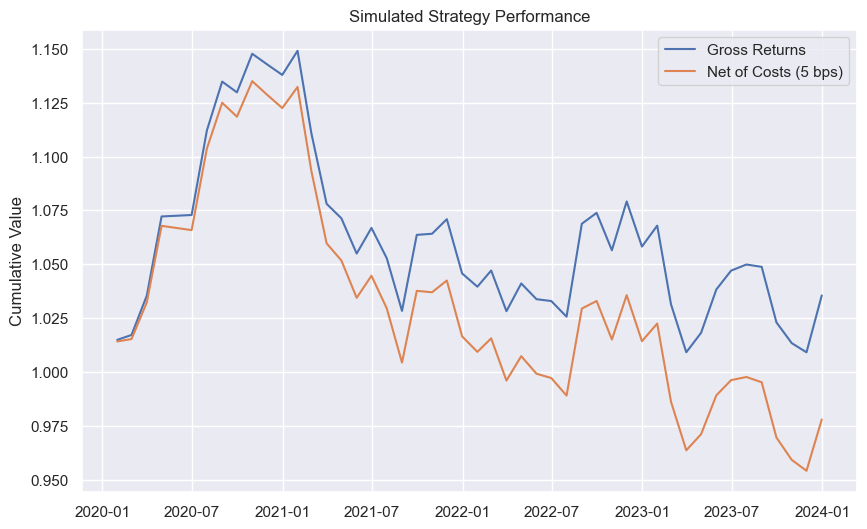

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(cum_raw.index, cum_raw, label="Gross Returns")
plt.plot(cum_net.index, cum_net, label="Net of Costs (5 bps)")
plt.title("Simulated Strategy Performance")
plt.ylabel("Cumulative Value")
plt.legend()
plt.show()